# Watermark detection and removal
## Sachi Kenjale

## Pipeline 1

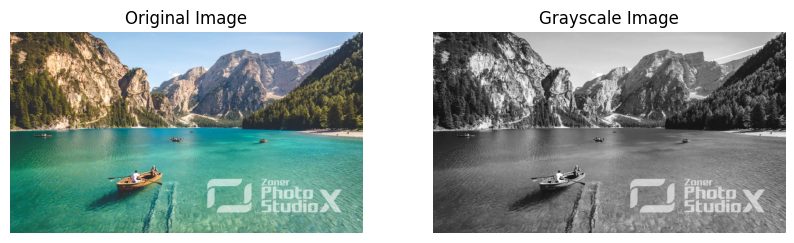

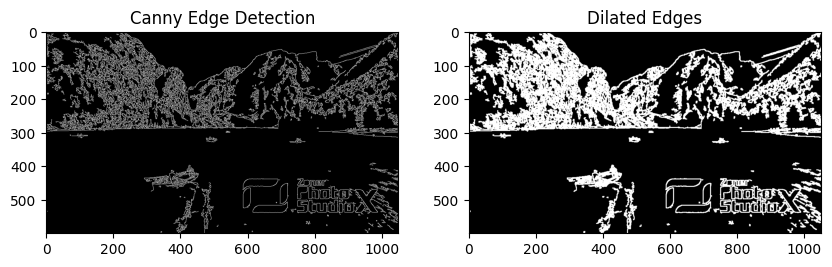

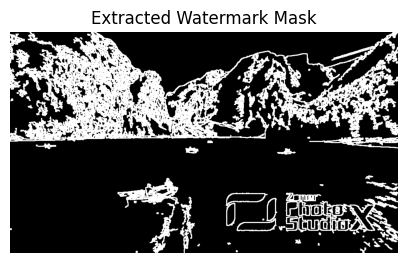

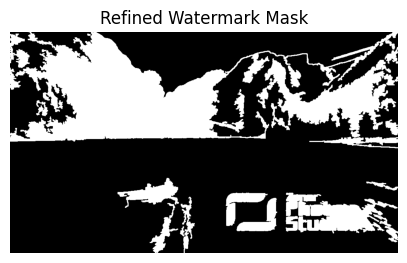

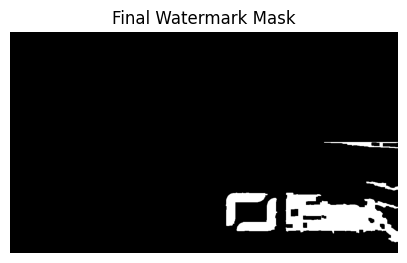

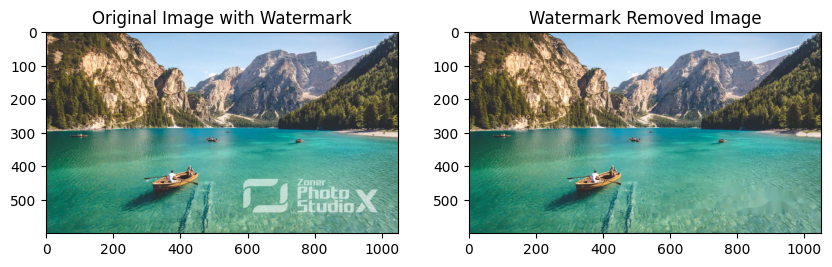

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("img_1.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original image
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

# Apply Canny Edge Detection
edges = cv2.Canny(gray, 110, 350)

# Apply morphological operations to clean up edges
kernel = np.ones((3,3), np.uint8)
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")

plt.subplot(1,2,2)
plt.imshow(edges_dilated, cmap="gray")
plt.title("Dilated Edges")
plt.show()


# Convert edges into a binary mask
watermark_mask = cv2.threshold(edges_dilated, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Display the extracted mask
plt.figure(figsize=(5,5))
plt.imshow(watermark_mask, cmap="gray")
plt.title("Extracted Watermark Mask")
plt.axis("off")
plt.show()


# Find contours in the binary mask
contours, _ = cv2.findContours(watermark_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank mask for the refined watermark
filtered_mask = np.zeros_like(watermark_mask)

# Retain only large contours (likely watermark)
for cnt in contours:
    if cv2.contourArea(cnt) > 500:  # Adjust threshold as needed
        cv2.drawContours(filtered_mask, [cnt], -1, (255), thickness=cv2.FILLED)

# Show refined mask
plt.figure(figsize=(5,5))
plt.imshow(filtered_mask, cmap="gray")
plt.title("Refined Watermark Mask")
plt.axis("off")
plt.show()

# Define ROI (Assuming watermark is in the bottom-right)
h, w = filtered_mask.shape
roi = filtered_mask[int(h*0.5):, int(w*0.5):]  # Crop bottom-right region

# Apply morphological closing (remove small gaps)
kernel = np.ones((7,7), np.uint8)
final_mask = cv2.morphologyEx(roi, cv2.MORPH_CLOSE, kernel)

# Expand back to full image size
refined_mask = np.zeros_like(filtered_mask)
refined_mask[int(h*0.5):, int(w*0.5):] = final_mask

# Display refined mask
plt.figure(figsize=(5,5))
plt.imshow(refined_mask, cmap="gray")
plt.title("Final Watermark Mask")
plt.axis("off")
plt.show()


# Apply inpainting
final_inpainted = cv2.inpaint(image, refined_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

# Display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image with Watermark")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(final_inpainted, cv2.COLOR_BGR2RGB))
plt.title("Watermark Removed Image")

plt.show()

## Pipeline 2

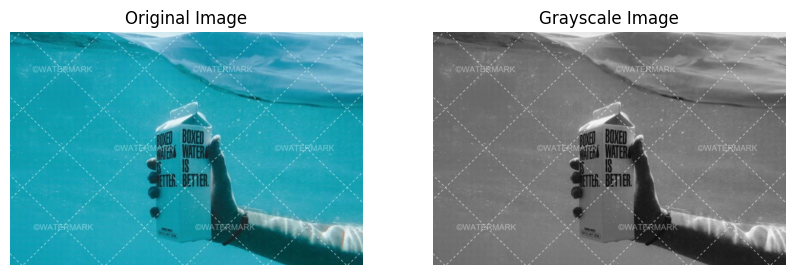

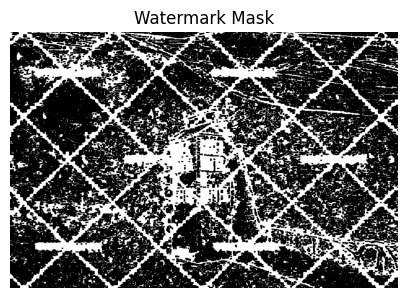

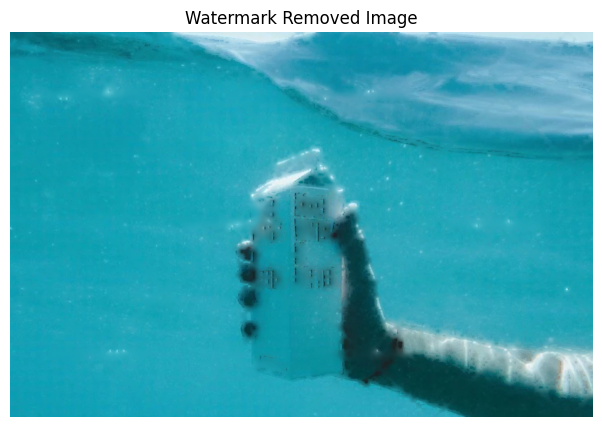

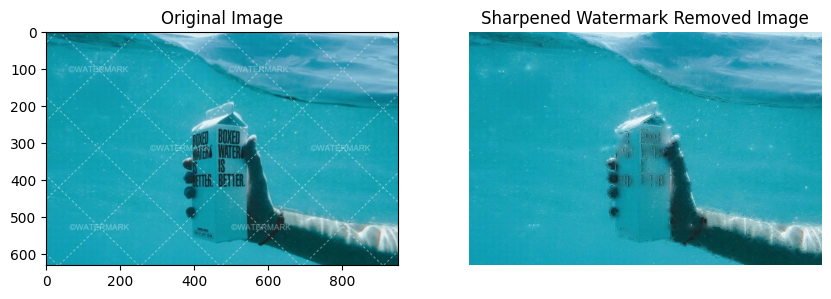

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("img_2.jpeg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original image
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()


# Apply Adaptive Thresholding to improve segmentation
thresholded_image = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 5, 2)

# Remove small noise with Morphological Closing
morph_kernel = np.ones((3,4), np.uint8)
denoised_mask = cv2.morphologyEx(thresholded_image, cv2.MORPH_CLOSE, morph_kernel)

# Display new mask
plt.figure(figsize=(5,5))
plt.imshow(denoised_mask, cmap="gray")
plt.title("Watermark Mask")
plt.axis("off")
plt.show()


# Apply inpainting
final_image = cv2.inpaint(image, denoised_mask, inpaintRadius=15, flags=cv2.INPAINT_TELEA)

# Display final result
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.title("Watermark Removed Image")
plt.axis("off")

plt.show()


# Apply sharpening filter
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened = cv2.filter2D(final_image, -1, kernel)

# Display final result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

# Show the final improved image
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("Sharpened Watermark Removed Image")
plt.axis("off")
plt.show()